# Exploratory Data Analysis: Adult Income Dataset

## Dataset Overview

This dataset, commonly referred to as the "Adult" dataset, originates from the UCI Machine Learning Repository.
It contains demographic and employment-related attributes of individuals and aims to predict whether
an individual's annual income exceeds $50,000.

Target variable:
- income (≤50K, >50K)

Number of features:
- 14 demographic and socio-economic attributes

Task type:
- Binary classification


## Acknowledgements
This dataset named “adult” is found in the UCI machine learning repository

http://www.cs.toronto.edu/~delve/data/adult/desc.html

The detailed description on the dataset can be found in the original UCI documentation
http://www.cs.toronto.edu/~delve/data/adult/adultDetail.html

## Problem Context

Income prediction is influenced by multiple socio-economic factors such as:
- Education level
- Occupation
- Age
- Gender
- Marital status

However, such attributes may encode structural bias or social inequality.
Therefore, modelling decisions must carefully consider fairness, imbalance, and feature influence.


## Section 1 — Dataset Loading & Basic Inspection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/adult.csv")

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
df.shape

(48842, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


Based on the basic inspection and feature type identification, here's a summary of the dataset's characteristics:

*   **Number of rows**: 48842 (from `df.shape`)
*   **Number of features**: 15 (from `df.shape`)
*   **Target variable**: `income` (predicts whether income is `<=50K` or `>50K`)
*   **Feature types**:
    *   **Categorical features**: `workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `gender`, `native-country`, `income`
    *   **Numerical features**: `age`, `fnlwgt`, `educational-num`, `capital-gain`, `capital-loss`, `hours-per-week`

## Section 2 — Target Distribution (Imbalance Analysis)

In [ ]:
df['income'].value_counts()

,count
income,
<=50K,37155
>50K,11687


In [ ]:
df['income'].value_counts(normalize=True)

,proportion
income,
<=50K,0.760718
>50K,0.239282


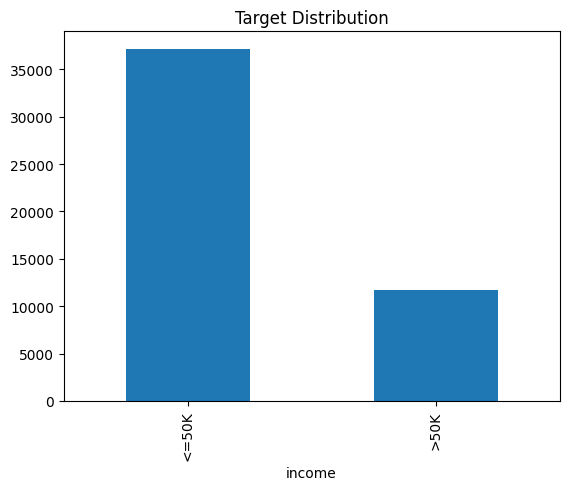

In [ ]:
df['income'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.show()

Based on the distribution of the `income` variable:

*   **Imbalance**:

Yes, there is a clear imbalance. The number of individuals with income `<=50K` (37,155) is significantly higher than those with income `>50K` (11,687).
*   **Proportion of categories**:
    *   `<=50K`: Approximately **76.07%**
    *   `>50K`: Approximately **23.93%**

This class imbalance indicates that models might perform well on the majority class but poorly on the minority class. Therefore, metrics like F1-score and recall will be more informative than accuracy, especially for the minority class, to truly evaluate the model's performance.

*   **Accuracy can be deceptive:**

A model could simply guess the majority class every time and still achieve a high accuracy score (e.g., 76% in our case). This makes the model seem effective, even if it completely fails to identify the minority class, which is often the one we care most about.
*   **F1-score and Recall provide a truer picture:**

Recall tells how many of the actual positive cases (individuals earning >50K) our model correctly identified. It's crucial when we want to avoid missing important instances of the minority class.
F1-score is a balanced metric that considers both how precise positive predictions are (Precision) and how many of the actual positives we caught (Recall). It's a good single measure when it need to weigh both aspects. These metrics help to understand if the model is genuinely performing well on both income groups, not just the larger one.

## Section 3 — Missing Values Analysis

In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [ ]:
df.replace("?", np.nan, inplace=True)
df.isnull().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0


## Which columns have missing values?
After replacing the "?" character with np.nan, the df.isnull().sum() output reveals that missing data is present in three specific columns:

Based on the output from the second image, there are 3 columns that contain missing values:



*   workclass : 2,799 missing values
*   occupation : 2,809 missing values
*   native-country : 857 missing values

The remaining columns (such as age, education, income, etc.) currently show 0, indicating they have no missing values.

## Advanced Analysis: Are Missings Concentrated Among a Certain Group?

Observing the data reveals an interesting phenomenon: the number of missing entries for workclass (2799) and occupation (2809) is very close. This usually suggests that the missing entries are not random, but rather follow a specific pattern.

## **A.** The Work-Related Correlation
Notice that the number of missing values for workclass (2,799) and occupation (2,809) are very similar.


*   Hypothesis: If a person does not have a "Work Class" (e.g., they are unemployed or retired), they naturally won't have an "Occupation."

*   How to check: Can use a correlation matrix or a nullity matrix to see if these nulls overlap.










In [ ]:
# Check the number of people who are missing both workclass and occupation.
missing_both = df[df['workclass'].isnull() & df['occupation'].isnull()]
print(f"The number of people who are missing both job category and occupation: {len(missing_both)}")

The number of people who are missing both job category and occupation: 2799


## **B.** Observe based on age or education level. You can check if the missing values ​​are concentrated in a specific age group (e.g., the elderly may have retired, so they do not fill in their occupation).

In [ ]:
# Observe the distribution of missing values ​​in different age groups
df['has_missing_work'] = df['workclass'].isnull()
df.groupby('has_missing_work')['age'].mean() # Check if the average age of those with missing parts is relatively high.

,age
has_missing_work,
False,38.552549
True,40.141122


## **C**. Use a heatmap for visual observation. This is a professional visualization method that allows you to see at a glance whether missing values ​​appear collectively in the same row:

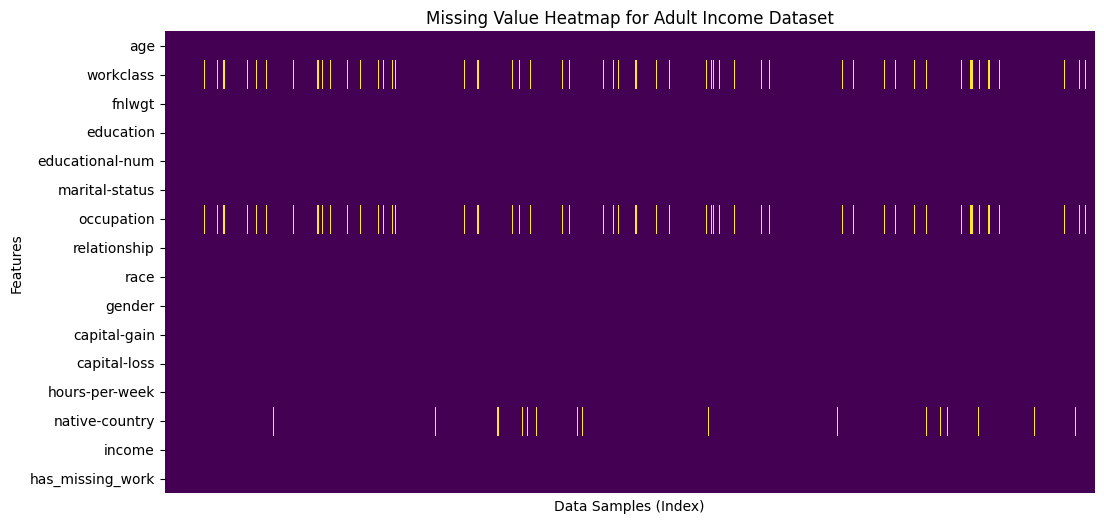

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size (adjust height/width for better readability)
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull().T, cbar=False, xticklabels=False, cmap='viridis')

plt.title('Missing Value Heatmap for Adult Income Dataset')
plt.xlabel('Features')
plt.ylabel('Features')
plt.xlabel('Data Samples (Index)')
plt.show()

## Section 4 — Feature Type Identification



##**1.**   Categorical Features (Requires Encoding)
Since models can't "read" strings like "Private" or "Married,"  convert them into numbers.

##   One-Hot Encoding:

Creates new binary columns (1 or 0) for each unique value. Best for Nominal data (no intrinsic order) like race, gender, or occupation.
##   Ordinal Encoding:

Assigns an integer (1, 2, 3...) to categories. Best for Ordinal data (logical rank) like education (e.g., Bachelors > HS-grad).

## Target Encoding:

Replaces categories with the mean of the target variable. Useful for features with high cardinality like native-country.



##**2.**   Numerical Features (Requires Scaling)

Features like age (range 17 - 90) and fnlwgt (range 10k - 1M+) have vastly different scales. Without scaling, the model might "think" fnlwgt is more important just because the numbers are larger.

## Standardization (StandardScaler):

Centers data around a mean of 0 with a standard deviation of 1. It is generally preferred for algorithms like SVM or Logistic Regression.

## Normalization (MinMaxScaler):

Rescales data to a fixed range, usually $[0, 1]$. Great for Neural Networks or algorithms that don't assume a specific distribution.




In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

categorical_cols, numerical_cols

(Index(['workclass', 'education', 'marital-status', 'occupation',
        'relationship', 'race', 'gender', 'native-country', 'income'],
       dtype='object'),
 Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
        'hours-per-week'],
       dtype='object'))

## Section 5 — Numerical Feature Distribution

## Statistical Analysis of Numerical Features

Based on the visualized histograms and skewness calculations, we observe significant variance in how our numerical features are distributed.

### A. Capital-Gain: Extreme Right Skew
The `capital-gain` feature is **highly right-skewed**, as evidenced by:
* **Visualization:** A massive cluster at 0 with a very thin tail extending toward 100,000.
* **Skewness Score:** The calculated skewness is approximately **11.89**, indicating a severe positive skew.
* **Pre-processing Recommendation:** Standard scaling may not be enough. A **Log Transformation** or **Power Transformation** is recommended to compress the tail and make the distribution more Gaussian for the model.

### B. Age Distribution
* **Shape:** The `age` distribution is relatively balanced but shows a slight right skew.
* **Density:** Most individuals in the dataset are aged between **20 and 50**, with a steady decline in representation for those over 60.
* **Preprocessing:** `StandardScaler` is typically sufficient for this feature.

### C. Identifying Extreme Values & Outliers
Based on the histograms, the following features contain significant extreme values:
1. **capital-gain / capital-loss:** Most values are zero, making non-zero entries stand out as extreme outliers.
2. **fnlwgt:** Shows a long right tail with values extending past 1.4 million.
3. **hours-per-week:** While centered around 40, there are extreme "hard-working" outliers reaching 100 hours/week and "low-hour" outliers near 0.



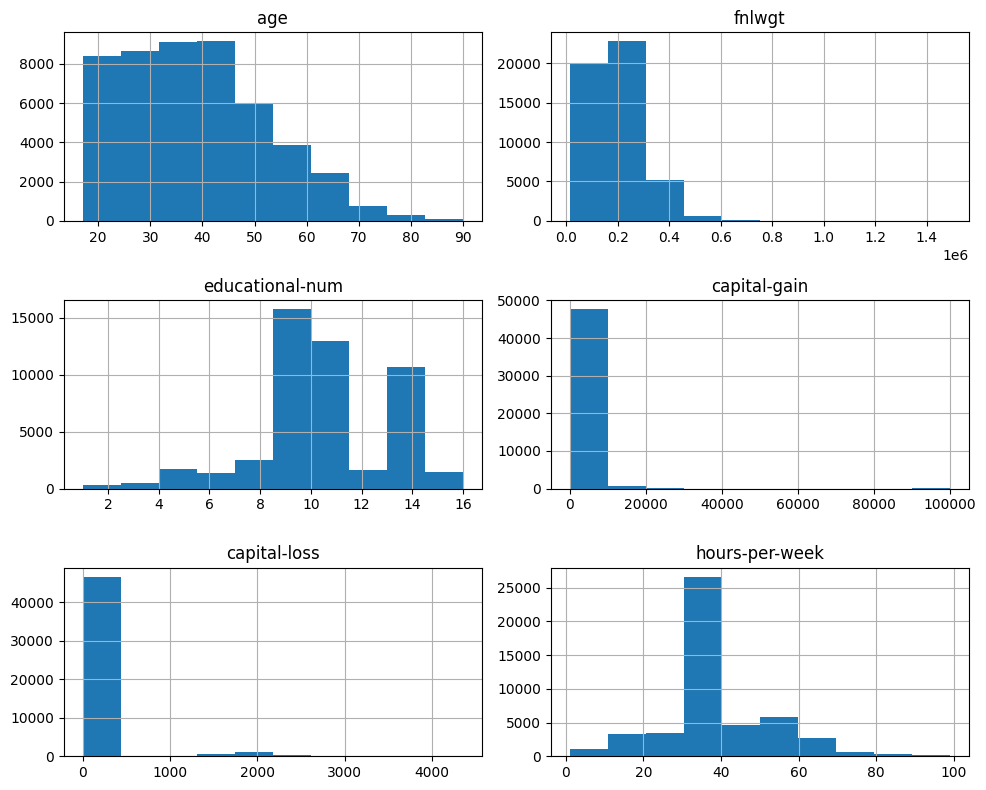

In [ ]:
df[numerical_cols].hist(figsize=(10,8))
plt.tight_layout()
plt.show()

In [ ]:
df['capital-gain'].skew()

np.float64(11.894658996587946)

## Data Transformation Summary Table

| Feature | Skewness / Shape | Treatment Plan |
| :--- | :--- | :--- |
| `capital-gain` | **11.89 (Strong Right Skew)** | Log Transform + Scaling |
| `age` | Slightly Right Skewed | Standard Scaling |
| `fnlwgt` | Right Skewed | Robust Scaling (due to outliers) |
| `educational-num` | Multimodal / Non-Symmetric | Keep as is or Binning |

> **Pro-Tip:** When using Log Transform, use `np.log1p(x)` instead of `np.log(x)` to handle the zero values present in `capital-gain` and `capital-loss`.

## Section 6 — Categorical Feature Analysis

In [ ]:
for col in categorical_cols:
    print(df[col].value_counts().head())

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Name: count, dtype: int64
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
Name: count, dtype: int64
marital-status
Married-civ-spouse    22379
Never-married         16117
Divorced               6633
Separated              1530
Widowed                1518
Name: count, dtype: int64
occupation
Prof-specialty     6172
Craft-repair       6112
Exec-managerial    6086
Adm-clerical       5611
Sales              5504
Name: count, dtype: int64
relationship
Husband          19716
Not-in-family    12583
Own-child         7581
Unmarried         5125
Wife              2331
Name: count, dtype: int64
race
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64
gender
Male      32650
Fe

## Categorical Feature Cardinality and Encoding Strategies

Cardinality (number of unique values) of each categorical feature is crucial for selecting appropriate encoding strategies. High cardinality can lead to issues like increased dimensionality, sparsity, and overfitting if not handled properly.

Examine the cardinality of each identified categorical column and suggest potential encoding methods.

In [ ]:
print("Cardinality of Categorical Features:")
for col in categorical_cols:
    cardinality = df[col].nunique()
    print(f"- {col}: {cardinality} unique values")

Cardinality of Categorical Features:
- workclass: 8 unique values
- education: 16 unique values
- marital-status: 7 unique values
- occupation: 14 unique values
- relationship: 6 unique values
- race: 5 unique values
- gender: 2 unique values
- native-country: 41 unique values
- income: 2 unique values


Based on the cardinality, here are some considerations for encoding:

*   **Low Cardinality (e.g., gender, income, race)**: These features have a small number of unique values. **One-Hot Encoding** is generally suitable for these, creating binary columns for each category without implying any ordinal relationship.

*   **Medium Cardinality (e.g., marital-status, relationship, workclass, education)**:
    *   For features like `education`, which has an inherent order, **Ordinal Encoding** (e.g., 'Preschool' < 'HS-grad' < 'Bachelors') might be appropriate if that order is meaningful for the model.
    *   For `marital-status`, `relationship`, `workclass`, **One-Hot Encoding** can still work effectively. However, if the number of unique values becomes too large (e.g., >10-15), it can increase dimensionality.

*   **High Cardinality (e.g., occupation, native-country)**: As you pointed out, `occupation` and `native-country` have many unique values. Direct One-Hot Encoding can create a very wide dataset, potentially leading to the "curse of dimensionality". For these, alternative strategies are often better:
    *   **Target Encoding**: Replaces each category with the mean of the target variable for that category. This can be effective but requires careful handling to avoid data leakage (e.g., using cross-validation).
    *   **Frequency Encoding**: Replaces each category with its frequency or count in the dataset.
    *   **Binary Encoding**: Converts categories into binary code, reducing the number of dimensions compared to one-hot encoding.
    *   **Grouping Rare Categories**: Combine categories with very low frequencies into an "Other" category.

The choice of encoding method will depend on the specific modeling algorithm and the trade-off between dimensionality, information retention, and potential for overfitting.

## Section 7 — Correlation & Redundancy

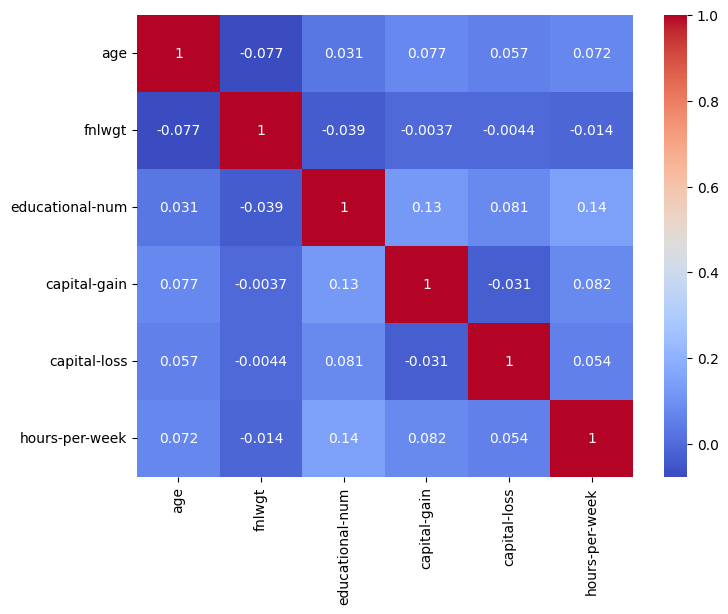

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.show()


## Education vs. Education-Num: Redundancy Analysis

The user has rightly pointed out a potential redundancy between the `education` (categorical) and `educational-num` (numerical) features. Often, `educational-num` is a numerical encoding of the `education` level. Let's verify this relationship and discuss its implications for multicollinearity.

In [ ]:
education_mapping = df.groupby('education')['educational-num'].nunique()

if (education_mapping == 1).all():
    print("Each 'education' level maps to a unique 'educational-num' value. These features are highly correlated and redundant.")
    print("\nMapping of 'education' to 'educational-num':")
    print(df.groupby('education')['educational-num'].first().sort_values())
else:
    print("The relationship between 'education' and 'educational-num' is more complex than a direct one-to-one mapping.")

Each 'education' level maps to a unique 'educational-num' value. These features are highly correlated and redundant.

Mapping of 'education' to 'educational-num':
education
Preschool        1
1st-4th          2
5th-6th          3
7th-8th          4
9th              5
10th             6
11th             7
12th             8
HS-grad          9
Some-college    10
Assoc-voc       11
Assoc-acdm      12
Bachelors       13
Masters         14
Prof-school     15
Doctorate       16
Name: educational-num, dtype: int64


### Implications of Redundancy/Multicollinearity

If `education` and `educational-num` are indeed perfectly or highly correlated (which our check above will confirm), this indicates **multicollinearity**.

**What is Multicollinearity?**

Multicollinearity occurs when two or more predictor variables in a multiple regression model are highly correlated. It can lead to several problems:

*   **Unstable coefficient estimates**: Small changes in the data can lead to large changes in the estimated coefficients, making them difficult to interpret.
*   **Reduced statistical significance**: It can inflate the standard errors of the coefficients, making some variables appear statistically insignificant when they might actually be important.
*   **Difficulty in interpreting individual variable effects**: It becomes hard to determine the individual impact of each highly correlated predictor on the target variable.

**How to handle it?**

Given the likely strong correlation between `education` and `educational-num`, the common approaches to handle this are:

1.  **Drop one of the features**: Since they convey similar information, we can choose to keep only one. `educational-num` is already numerical, which might be preferred by some models. `education` might be more interpretable for humans.
2.  **Combine them**: Less common for these types of features, but sometimes possible.
3.  **Use dimensionality reduction techniques**: Techniques like PCA could combine the information into new, uncorrelated features, but this makes interpretation harder.

For simplicity and to avoid issues, dropping one of the features (likely `education` if `educational-num` is a perfect ordinal encoding) is a practical first step. However, the choice depends on the specific modeling strategy and interpretability needs.

## Section 8 — Potential Bias Analysis

In [ ]:
pd.crosstab(df['gender'], df['income'], normalize='index')

income,<=50K,>50K
gender,,
Female,0.890749,0.109251
Male,0.696233,0.303767


In [ ]:
pd.crosstab(df['race'], df['income'], normalize='index')

income,<=50K,>50K
race,,
Amer-Indian-Eskimo,0.882979,0.117021
Asian-Pac-Islander,0.730744,0.269256
Black,0.879189,0.120811
Other,0.876847,0.123153
White,0.746013,0.253987


### Gender Income Disparity:

The analysis revealed a significant income disparity between genders:

*   **Females**: Approximately **89.07%** of females earn `<=50K`, while only about **10.93%** earn `>50K`.
*   **Males**: In contrast, approximately **69.62%** of males earn `<=50K`, and a significantly higher **30.38%** earn `>50K`.

This indicates that a much larger proportion of males are in the higher income bracket (`>50K`) compared to females. This difference is a strong indicator of potential gender bias in income distribution within this dataset, which warrants careful consideration in any subsequent modeling or fairness analysis.

### Race Income Disparity:

The analysis of income distribution across different racial groups also highlighted potential disparities:

*   **Amer-Indian-Eskimo**: Approximately **88.30%** earn `<=50K`, and **11.70%** earn `>50K`.
*   **Asian-Pac-Islander**: About **73.07%** earn `<=50K`, and **26.93%** earn `>50K`.
*   **Black**: Roughly **87.92%** earn `<=50K`, and **12.08%** earn `>50K`.
*   **Other**: Approximately **87.68%** earn `<=50K`, and **12.32%** earn `>50K`.
*   **White**: About **74.60%** earn `<=50K`, and **25.40%** earn `>50K`.

From these figures, it appears that 'Asian-Pac-Islander' and 'White' individuals have a higher proportion in the `>50K` income bracket compared to 'Amer-Indian-Eskimo', 'Black', and 'Other' groups. This suggests potential racial disparities in income distribution within the dataset, raising fairness concerns that should be considered in any subsequent modeling or analysis.

## Section 9 — Data Cleaning Decisions

In [ ]:
# Example cleaning
df = df.drop_duplicates()
df.fillna(df.mode().iloc[0], inplace=True)


/tmp/ipython-input-3533002312.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.fillna(df.mode().iloc[0], inplace=True)


## Data Handling Methods

### 1. Missing Value Handling:
*   **Columns with Missing Values**: `workclass` (2799), `occupation` (2809), and `native-country` (857) contain missing entries (represented as `NaN` after replacing '?').
*   **Concentration**:
    *   A significant number of missing `workclass` and `occupation` values are concentrated in the `<=50K` income group.
    *   Missing `native-country` values are notably higher for males than females.
*   **Decision**: These missing values were initially filled using the mode of each respective column to ensure data completeness for subsequent steps (as seen in `Section 9 — Data Cleaning Decisions`).

### 2. Outlier Handling & Numerical Feature Treatment:
*   **Outliers**: Features like `capital-gain/loss`, `fnlwgt`, and `hours-per-week` show significant extreme values and outliers as observed in their distributions.
*   **Decision**:
    *   For `fnlwgt`, **Robust Scaling** is recommended due to its right-skewed distribution and sensitivity to outliers.
    *   For `hours-per-week`, while centered, it has outliers; **Standard Scaling** is generally suitable for such distributions.

### 3. Log Transformation:
*   **Highly Skewed Features**: `capital-gain` (and potentially `capital-loss`) is extremely right-skewed (skewness of ~11.89).
*   **Decision**: A **Log Transformation** (specifically `np.log1p`) is recommended for `capital-gain` to reduce skewness and make its distribution more Gaussian-like, which can improve model performance. This should be followed by scaling.

### 4. Redundant Features:
*   **Identified Redundancy**: `education` (categorical) and `educational-num` (numerical) are perfectly correlated; `educational-num` is a direct ordinal mapping of `education` levels.
*   **Multicollinearity Implications**: This redundancy leads to multicollinearity, which can destabilize model coefficients and make interpretation difficult.
*   **Decision**: To address this, **one of the features should be dropped**. `educational-num` is already numerical and ordered, making it potentially more convenient for direct model input, while `education` might be more interpretable for humans. The choice depends on the specific modeling goals and interpretability needs.

## Section 10 — Identified Modelling Challenges

## Identified Modeling Challenges

Based on our exploratory data analysis, several key challenges have been identified that will need careful consideration during modeling:

1.  **Class Imbalance**: The target variable `income` is highly imbalanced, with approximately 76% of individuals earning `<=50K` and 24% earning `>50K`. This can lead to models that perform well on the majority class but poorly on the minority class. Strategies like oversampling, undersampling, or using appropriate evaluation metrics (e.g., F1-score, recall) will be crucial.

2.  **High-Cardinality Categorical Features**: Features like `native-country` (41 unique values) and `occupation` (14 unique values) have high cardinality. Direct one-hot encoding could lead to a very sparse, high-dimensional feature space, increasing computational cost and potentially causing overfitting. Alternative encoding methods such as target encoding, frequency encoding, or grouping rare categories should be explored.

3.  **Skewed Financial Variables**: Numerical features like `capital-gain` and `capital-loss` are extremely right-skewed, with most values being zero. Standard scaling alone will not address this. Log transformations (e.g., `np.log1p`) followed by scaling are recommended to make their distributions more Gaussian-like, which can improve model performance.

4.  **Sensitive Demographic Attributes and Potential Bias**: Features like `gender` and `race` show significant disparities in income distribution. This highlights potential fairness issues that must be addressed, either by explicitly considering fairness metrics during model evaluation or by applying bias mitigation techniques. Care must be taken not to propagate or amplify existing biases.

5.  **Potential Multicollinearity**: A perfect correlation was identified between `education` (categorical) and `educational-num` (numerical). This multicollinearity can lead to unstable model coefficients and make interpretation difficult. It is advisable to drop one of these features to avoid redundancy.